# 02. IEMOCAP Feature Extraction: Emotion2Vec + Acoustic Features

Notebook này là bước thứ hai trong pipeline **Emotion2Vec-Guided Acoustic Cross-Attention Multi-Task SER**.

Mục tiêu:

1. Chuẩn hóa audio theo một pipeline rõ ràng trước khi trích đặc trưng.
2. Trích đặc trưng chính từ pretrained model `emotion2vec`.
3. Trích đặc trưng phụ từ acoustic features: MFCC, log-Mel, pitch/F0, RMS energy, ZCR, chroma, spectral contrast, tonnetz và statistical functionals.
4. Minh họa trực quan đặc trưng theo 4 emotion: `neutral`, `angry`, `sad`, `happy`.
5. Tạo các bảng report để biết mỗi feature dùng để làm gì, học từ bài báo nào, và sẽ đi vào branch/model nào.
6. Lưu feature cache để notebook train 5-fold và 10-fold dùng lại.

Notebook này ưu tiên **giải thích + kiểm chứng dữ liệu + lưu cache**, chưa train model.

## 1. Vì sao phải chuẩn hóa audio trước khi trích đặc trưng?

Tất cả nhánh feature nên bắt đầu từ cùng một waveform đã chuẩn hóa:

```text
audio file
-> load audio
-> mono
-> resample 16kHz
-> optional normalize
-> segmentation/padding
-> feature extraction
```

Lý do:

- `emotion2vec`, `HuBERT`, `wav2vec2`, `WavLM` thường nhận raw waveform 16kHz.
- MFCC/log-Mel/pitch nếu trích từ sample rate khác nhau thì feature không còn cùng chuẩn.
- Segmentation giúp xử lý utterance dài mà không crop mất tín hiệu cảm xúc.
- Normalize giúp giảm khác biệt volume, nhưng phải làm nhẹ vì energy/arousal cũng là tín hiệu cảm xúc.

Trong các bài tham chiếu:

- **HuBERT/wav2vec2/emotion2vec**: dùng raw waveform đã đưa về chuẩn model, không cần MFCC trước.
- **CA-MSER**: dùng waveform, MFCC, spectrogram/log-spec và wav2vec2; họ segment/pad các chuỗi feature về độ dài thống nhất.
- **SpeechFormer/DST**: dùng log-Mel/wav2vec/WavLM features đã được chuẩn hóa theo pipeline trước.
- **Multi-task 2401.00536**: dùng HuBERT-large để extract acoustic embeddings và DeBERTaV3-large để extract text embeddings; paper không mô tả chi tiết load/resample, nhưng HuBERT yêu cầu waveform đúng chuẩn.

In [1]:
from pathlib import Path
import os
import json
import math
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display, Markdown, Audio
except Exception:
    display = print
    Markdown = lambda x: x
    Audio = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != "Speech Project" and PROJECT_ROOT.parent.name == "Speech Project":
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

BASE_DIR = PROJECT_ROOT / "06_w2v_based_models"
FOLDER01 = BASE_DIR / "01IEMOCAP Dataset Analysis and Speaker-Independent Splits"
NOTEBOOK_DIR = BASE_DIR / "02IEMOCAP Feature Extraction Emotion2Vec Acoustic"

METADATA_PATH = FOLDER01 / "metadata" / "iemocap_4class_avd_metadata.csv"
REPORT_DIR = NOTEBOOK_DIR / "reports"
FIGURE_DIR = NOTEBOOK_DIR / "figures"
CACHE_DIR = NOTEBOOK_DIR / "features_cache"
SAMPLE_DIR = NOTEBOOK_DIR / "sample_visualizations"

for folder in [REPORT_DIR, FIGURE_DIR, CACHE_DIR, SAMPLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16000
SEGMENT_SECONDS = 4.0
SEGMENT_OVERLAP = 0.5
MAX_SEGMENTS_PER_UTTERANCE = 8
RMS_NORMALIZE = False
TARGET_RMS = 0.05
PEAK_NORMALIZE = True
PEAK_TARGET = 0.95
RUN_FULL_EXTRACTION = False
MAX_DEMO_PER_EMOTION = 1

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("METADATA_PATH:", METADATA_PATH)
print("TARGET_SR:", TARGET_SR)

PROJECT_ROOT: D:\UTE\Speech Programming\Speech Project
NOTEBOOK_DIR: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\02IEMOCAP Feature Extraction Emotion2Vec Acoustic
METADATA_PATH: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\metadata\iemocap_4class_avd_metadata.csv
TARGET_SR: 16000


## 2. Bảng đặc trưng sẽ trích và lý do dùng

Bảng này là phần quan trọng để báo cáo: không chỉ nói “em trích MFCC/log-Mel”, mà phải biết **vì sao trích**, bài nào dùng, và sau này feature đi vào branch nào.

In [2]:
feature_reference_rows = [
    {
        "feature_group": "emotion2vec embeddings",
        "type": "pretrained SSL / emotion representation",
        "how_to_extract": "raw waveform 16kHz -> emotion2vec pretrained model -> embeddings/hidden states",
        "why_extract": "Backbone chính, học biểu diễn cảm xúc từ dữ liệu lớn tốt hơn handcrafted features.",
        "paper_or_model_reference": "emotion2vec: Self-Supervised Pre-Training for Speech Emotion Representation",
        "used_by_future_model": "main backbone / shared encoder",
    },
    {
        "feature_group": "MFCC + delta + delta-delta",
        "type": "handcrafted spectral-temporal",
        "how_to_extract": "librosa.feature.mfcc + librosa.feature.delta",
        "why_extract": "Mô tả spectral envelope và dynamic change của giọng nói; baseline SER truyền thống hay dùng.",
        "paper_or_model_reference": "CA-MSER uses MFCC branch; TIM-Net uses MFCC",
        "used_by_future_model": "1D CNN/BiLSTM acoustic support branch",
    },
    {
        "feature_group": "log-Mel + delta + delta-delta",
        "type": "time-frequency representation",
        "how_to_extract": "Mel spectrogram -> log scale -> delta features",
        "why_extract": "Biểu diễn năng lượng theo thời gian-tần số, phù hợp CNN/Transformer.",
        "paper_or_model_reference": "SpeechFormer uses log-Mel/spectrogram features; CA-MSER uses spectrogram branch",
        "used_by_future_model": "2D CNN / spectral branch",
    },
    {
        "feature_group": "Pitch/F0",
        "type": "prosody",
        "how_to_extract": "librosa.pyin or yin",
        "why_extract": "Pitch contour liên quan đến speaking style, arousal, tension, expressive speech.",
        "paper_or_model_reference": "Common SER prosody feature; openSMILE/eGeMAPS style features",
        "used_by_future_model": "prosody branch / statistical gate",
    },
    {
        "feature_group": "RMS energy",
        "type": "prosody/energy",
        "how_to_extract": "librosa.feature.rms",
        "why_extract": "Energy thường liên quan đến arousal; angry/happy có thể năng lượng cao hơn sad/neutral.",
        "paper_or_model_reference": "Common SER acoustic feature; eGeMAPS/openSMILE family",
        "used_by_future_model": "prosody branch / arousal support",
    },
    {
        "feature_group": "ZCR",
        "type": "temporal/spectral proxy",
        "how_to_extract": "librosa.feature.zero_crossing_rate",
        "why_extract": "Phản ánh noisiness/voicing proxy, hỗ trợ phân biệt một số biểu hiện giọng.",
        "paper_or_model_reference": "Traditional SER handcrafted acoustic feature",
        "used_by_future_model": "temporal support branch",
    },
    {
        "feature_group": "Chroma / Tonnetz",
        "type": "harmonic feature",
        "how_to_extract": "librosa.feature.chroma_stft, librosa.feature.tonnetz",
        "why_extract": "Có thể phản ánh harmonic/tonal movement; không phải feature chính nhưng dùng cho ablation.",
        "paper_or_model_reference": "General audio representation; optional for SER ablation",
        "used_by_future_model": "optional statistical/acoustic ablation",
    },
    {
        "feature_group": "Spectral contrast",
        "type": "spectral shape",
        "how_to_extract": "librosa.feature.spectral_contrast",
        "why_extract": "Đo contrast giữa spectral peaks/valleys, bổ sung shape information ngoài MFCC/log-Mel.",
        "paper_or_model_reference": "Traditional audio classification feature",
        "used_by_future_model": "statistical branch / ablation",
    },
    {
        "feature_group": "Statistical functionals",
        "type": "utterance-level summary",
        "how_to_extract": "mean, std, min, max, median, IQR, percentiles over frame features",
        "why_extract": "Biến frame-level features thành vector cố định; dùng cho MLP/gate và phân tích dữ liệu.",
        "paper_or_model_reference": "openSMILE/eGeMAPS style functionals; older SER baselines",
        "used_by_future_model": "statistical gate / auxiliary feature vector",
    },
]

feature_reference_df = pd.DataFrame(feature_reference_rows)
display(feature_reference_df)
feature_reference_df.to_csv(REPORT_DIR / "feature_reference_table.csv", index=False, encoding="utf-8-sig")

,feature_group,type,how_to_extract,why_extract,paper_or_model_reference,used_by_future_model
0,emotion2vec embeddings,pretrained SSL / emotion representation,raw waveform 16kHz -> emotion2vec pretrained model -> embeddings/hidden states,"Backbone chính, học biểu diễn cảm xúc từ dữ liệu lớn tốt hơn handcrafted features.",emotion2vec: Self-Supervised Pre-Training for Speech Emotion Representation,main backbone / shared encoder
1,MFCC + delta + delta-delta,handcrafted spectral-temporal,librosa.feature.mfcc + librosa.feature.delta,Mô tả spectral envelope và dynamic change của giọng nói; baseline SER truyền thống hay dùng.,CA-MSER uses MFCC branch; TIM-Net uses MFCC,1D CNN/BiLSTM acoustic support branch
2,log-Mel + delta + delta-delta,time-frequency representation,Mel spectrogram -> log scale -> delta features,"Biểu diễn năng lượng theo thời gian-tần số, phù hợp CNN/Transformer.",SpeechFormer uses log-Mel/spectrogram features; CA-MSER uses spectrogram branch,2D CNN / spectral branch
3,Pitch/F0,prosody,librosa.pyin or yin,"Pitch contour liên quan đến speaking style, arousal, tension, expressive speech.",Common SER prosody feature; openSMILE/eGeMAPS style features,prosody branch / statistical gate
4,RMS energy,prosody/energy,librosa.feature.rms,Energy thường liên quan đến arousal; angry/happy có thể năng lượng cao hơn sad/neutral.,Common SER acoustic feature; eGeMAPS/openSMILE family,prosody branch / arousal support
5,ZCR,temporal/spectral proxy,librosa.feature.zero_crossing_rate,"Phản ánh noisiness/voicing proxy, hỗ trợ phân biệt một số biểu hiện giọng.",Traditional SER handcrafted acoustic feature,temporal support branch
6,Chroma / Tonnetz,harmonic feature,"librosa.feature.chroma_stft, librosa.feature.tonnetz",Có thể phản ánh harmonic/tonal movement; không phải feature chính nhưng dùng cho ablation.,General audio representation; optional for SER ablation,optional statistical/acoustic ablation
7,Spectral contrast,spectral shape,librosa.feature.spectral_contrast,"Đo contrast giữa spectral peaks/valleys, bổ sung shape information ngoài MFCC/log-Mel.",Traditional audio classification feature,statistical branch / ablation
8,Statistical functionals,utterance-level summary,"mean, std, min, max, median, IQR, percentiles over frame features",Biến frame-level features thành vector cố định; dùng cho MLP/gate và phân tích dữ liệu.,openSMILE/eGeMAPS style functionals; older SER baselines,statistical gate / auxiliary feature vector


## 3. Load metadata từ notebook 01

Notebook 02 dùng file metadata do notebook 01 tạo:

```text
01.../metadata/iemocap_4class_avd_metadata.csv
```

Nếu chưa có file này, cần chạy notebook 01 sau khi cấu hình `IEMOCAP_ROOT`.

In [3]:
if METADATA_PATH.exists():
    metadata = pd.read_csv(METADATA_PATH)
    print("Loaded metadata:", metadata.shape)
    display(metadata.head())
else:
    metadata = pd.DataFrame()
    display(Markdown(f"""
### Chưa tìm thấy metadata train-ready

Notebook chưa thấy file:

```text
{METADATA_PATH}
```

Hãy chạy notebook 01 với `IEMOCAP_ROOT` đúng để tạo metadata trước. Notebook 02 vẫn có thể chạy các cell giải thích và tạo bảng reference, nhưng chưa thể trích feature thật.
"""))

Loaded metadata: (6877, 22)


,train_sample_id,utterance_id,conversation_id,session,speaker_id,gender,emotion_4class,emotion_id,original_emotion,valence,arousal,dominance,valence_norm,arousal_norm,dominance_norm,start_time,end_time,eval_duration,duration,sample_rate,channels,wav_path
0,iemocap_hf_00000,Ses01F_impro01_F000,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.666667,2.333333,2.000000,0.416667,0.333333,0.250000,0.0,1.945563,1.945563,1.945563,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F000.wav
1,iemocap_hf_00001,Ses01F_impro01_F001,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.333333,2.666667,2.333333,0.333333,0.416667,0.333333,0.0,1.382437,1.382437,1.382437,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F001.wav
2,iemocap_hf_00002,Ses01F_impro01_F002,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.666667,2.666667,2.666667,0.416667,0.416667,0.416667,0.0,3.130250,3.130250,3.130250,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F002.wav
3,iemocap_hf_00003,Ses01F_impro01_F003,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.333333,3.000000,3.000000,0.333333,0.500000,0.500000,0.0,1.497500,1.497500,1.497500,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F003.wav
4,iemocap_hf_00004,Ses01F_impro01_F004,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.666667,3.333333,2.666667,0.416667,0.583333,0.416667,0.0,3.414250,3.414250,3.414250,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F004.wav


## 4. Audio preprocessing: làm gì và tác dụng gì?

| Bước | Làm gì | Tác dụng | Lưu ý |
|---|---|---|---|
| Load audio | đọc file wav thành waveform | lấy tín hiệu thô | giữ float32 |
| Mono | nếu stereo thì average kênh | thống nhất input shape | IEMOCAP thường mono nhưng vẫn kiểm tra |
| Resample 16kHz | đưa sample rate về 16kHz | phù hợp emotion2vec/HuBERT/wav2vec2 | cũng giúp MFCC/log-Mel cùng chuẩn |
| Peak normalize | scale peak về mức cố định | tránh clipping/volume quá nhỏ | làm nhẹ, không bắt buộc |
| RMS normalize | scale loudness trung bình | giảm khác biệt volume | có thể làm mất energy/arousal nếu quá mạnh |
| Segmentation | cắt utterance dài thành segment | không crop mất phần cuối | cần lưu mapping segment -> utterance |
| Padding | pad segment ngắn | batch/model có input cùng length | pad bằng zero |

Khuyến nghị ban đầu:

```text
load -> mono -> 16kHz -> peak normalize nhẹ -> segment/pad
```

RMS normalize nên để ablation vì energy là tín hiệu quan trọng cho arousal.

In [4]:
try:
    import librosa
    LIBROSA_AVAILABLE = True
except Exception as exc:
    LIBROSA_AVAILABLE = False
    print("librosa unavailable:", exc)

try:
    import soundfile as sf
    SOUNDFILE_AVAILABLE = True
except Exception as exc:
    SOUNDFILE_AVAILABLE = False
    print("soundfile unavailable:", exc)

def load_audio_raw(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if SOUNDFILE_AVAILABLE:
        y, sr = sf.read(str(path), dtype="float32", always_2d=False)
        if y.ndim == 2:
            y = y.mean(axis=1)
        return y.astype(np.float32), int(sr)
    if LIBROSA_AVAILABLE:
        y, sr = librosa.load(str(path), sr=None, mono=True)
        return y.astype(np.float32), int(sr)
    raise ImportError("Need soundfile or librosa to load audio.")

def resample_audio(y, orig_sr, target_sr=TARGET_SR):
    if orig_sr == target_sr:
        return y.astype(np.float32)
    if not LIBROSA_AVAILABLE:
        raise ImportError("librosa is required for resampling in this notebook.")
    return librosa.resample(y.astype(np.float32), orig_sr=orig_sr, target_sr=target_sr).astype(np.float32)

def peak_normalize(y, target=PEAK_TARGET, eps=1e-8):
    peak = float(np.max(np.abs(y))) if len(y) else 0.0
    if peak < eps:
        return y.astype(np.float32)
    return (y / peak * target).astype(np.float32)

def rms_normalize(y, target=TARGET_RMS, eps=1e-8):
    rms = float(np.sqrt(np.mean(y ** 2))) if len(y) else 0.0
    if rms < eps:
        return y.astype(np.float32)
    return (y / rms * target).astype(np.float32)

def preprocess_audio(path, target_sr=TARGET_SR, peak_norm=PEAK_NORMALIZE, rms_norm=RMS_NORMALIZE):
    y, sr = load_audio_raw(path)
    original = {"original_sr": sr, "original_samples": len(y), "original_duration": len(y) / max(sr, 1)}
    y = resample_audio(y, sr, target_sr)
    if peak_norm:
        y = peak_normalize(y)
    if rms_norm:
        y = rms_normalize(y)
    processed = {
        **original,
        "target_sr": target_sr,
        "processed_samples": len(y),
        "processed_duration": len(y) / target_sr,
        "peak": float(np.max(np.abs(y))) if len(y) else 0.0,
        "rms": float(np.sqrt(np.mean(y ** 2))) if len(y) else 0.0,
    }
    return y.astype(np.float32), target_sr, processed

def segment_waveform(y, sr=TARGET_SR, segment_seconds=SEGMENT_SECONDS, overlap=SEGMENT_OVERLAP, max_segments=MAX_SEGMENTS_PER_UTTERANCE):
    segment_len = int(segment_seconds * sr)
    if segment_len <= 0:
        raise ValueError("segment_len must be positive")
    hop = max(1, int(segment_len * (1 - overlap)))
    if len(y) <= segment_len:
        padded = np.zeros(segment_len, dtype=np.float32)
        padded[:len(y)] = y
        return np.stack([padded]), [{"start_sample": 0, "end_sample": len(y), "padded": True}]
    segments, info = [], []
    for start in range(0, len(y), hop):
        end = start + segment_len
        chunk = y[start:end]
        if len(chunk) < segment_len:
            padded = np.zeros(segment_len, dtype=np.float32)
            padded[:len(chunk)] = chunk
            chunk = padded
            padded_flag = True
        else:
            padded_flag = False
        segments.append(chunk.astype(np.float32))
        info.append({"start_sample": start, "end_sample": min(end, len(y)), "padded": padded_flag})
        if len(segments) >= max_segments or end >= len(y):
            break
    return np.stack(segments), info

## 5. Chọn sample để minh họa

Notebook sẽ cố gắng chọn:

- `MAX_DEMO_PER_EMOTION` mẫu cho mỗi emotion.
- Cặp **cùng speaker, khác emotion** nếu có.
- Cặp **cùng emotion, khác speaker** nếu có.
- Cặp **cùng conversation** nếu metadata cho phép.

Những cặp này giúp trả lời:

- Cùng một người nói nhưng emotion khác thì feature thay đổi như thế nào?
- Cùng emotion nhưng người nói khác thì feature có ổn định không?
- Trong cùng conversation, emotion khác nhau biểu hiện ra sao?

In [5]:
FOUR_CLASS_EMOTIONS = ["neutral", "angry", "sad", "happy"]

def existing_audio_metadata(df):
    if df.empty or "wav_path" not in df.columns:
        return pd.DataFrame()
    out = df.copy()
    out["wav_exists"] = out["wav_path"].apply(lambda p: Path(str(p)).exists())
    return out[out["wav_exists"]].reset_index(drop=True)

audio_metadata = existing_audio_metadata(metadata)
print("Rows with existing wav:", len(audio_metadata))

if audio_metadata.empty:
    demo_samples = pd.DataFrame()
    display(Markdown("Chưa có audio thực tế để chọn sample minh họa. Sau khi cấu hình IEMOCAP_ROOT và chạy notebook 01, cell này sẽ chọn mẫu tự động."))
else:
    demo_parts = []
    for emotion in FOUR_CLASS_EMOTIONS:
        sub = audio_metadata[audio_metadata["emotion_4class"].eq(emotion)]
        if not sub.empty:
            demo_parts.append(sub.sample(min(MAX_DEMO_PER_EMOTION, len(sub)), random_state=42))
    demo_samples = pd.concat(demo_parts).drop_duplicates("train_sample_id").reset_index(drop=True)
    display(demo_samples[["train_sample_id", "utterance_id", "speaker_id", "session", "emotion_4class", "duration", "wav_path"]])
    demo_samples.to_csv(REPORT_DIR / "selected_demo_samples.csv", index=False, encoding="utf-8-sig")

Rows with existing wav: 6877


,train_sample_id,utterance_id,speaker_id,session,emotion_4class,duration,wav_path
0,iemocap_hf_02669,Ses02F_script03_2_M009,Ses02M,Ses02,neutral,4.150000,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses02F_script03_2_M009.wav
1,iemocap_hf_09638,Ses05M_script01_1b_M040,Ses05M,Ses05,angry,2.607687,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses05M_script01_1b_M040.wav
2,iemocap_hf_05040,Ses03M_impro06_M014,Ses03M,Ses03,sad,3.139500,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses03M_impro06_M014.wav
3,iemocap_hf_01008,Ses01M_impro03_M007,Ses01M,Ses01,happy,8.082500,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01M_impro03_M007.wav


## 6. Hàm trích acoustic features

Các feature được chia thành 4 nhóm:

```text
temporal/prosody: RMS, ZCR, pitch/F0
cepstral: MFCC, delta, delta-delta
spectral image: log-Mel, delta log-Mel, delta-delta log-Mel
utterance statistics: mean/std/min/max/median/IQR/percentiles
```

Ở bản model sau, không nhất thiết dùng tất cả feature cùng lúc. Ta sẽ dùng notebook này để tạo cache và làm ablation.

In [6]:
from scipy import signal
from scipy.fft import dct

def frame_signal(y, frame_length=512, hop_length=320):
    y = np.asarray(y, dtype=np.float32)
    if len(y) < frame_length:
        padded = np.zeros(frame_length, dtype=np.float32)
        padded[:len(y)] = y
        y = padded
    n_frames = 1 + max(0, (len(y) - frame_length) // hop_length)
    frames = np.stack([y[i * hop_length:i * hop_length + frame_length] for i in range(n_frames)])
    return frames

def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel):
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def mel_filterbank(sr=TARGET_SR, n_fft=512, n_mels=64, fmin=0.0, fmax=None):
    fmax = fmax or sr / 2
    mel_points = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sr).astype(int)
    fb = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float32)
    for m in range(1, n_mels + 1):
        left, center, right = bins[m - 1], bins[m], bins[m + 1]
        if center > left:
            fb[m - 1, left:center] = (np.arange(left, center) - left) / max(center - left, 1)
        if right > center:
            fb[m - 1, center:right] = (right - np.arange(center, right)) / max(right - center, 1)
    return fb

def fast_delta(x):
    x = np.asarray(x, dtype=np.float32)
    if x.shape[-1] < 2:
        return np.zeros_like(x)
    return np.gradient(x, axis=-1).astype(np.float32)

def extract_frame_features(y, sr=TARGET_SR, n_mfcc=20, n_mels=64, n_fft=512, hop_length=320, win_length=512):
    y = np.asarray(y, dtype=np.float32)
    freqs, times, zxx = signal.stft(
        y,
        fs=sr,
        window="hann",
        nperseg=win_length,
        noverlap=max(0, win_length - hop_length),
        nfft=n_fft,
        boundary=None,
        padded=False,
    )
    power = (np.abs(zxx) ** 2).astype(np.float32) + 1e-10
    if power.shape[1] == 0:
        power = np.zeros((n_fft // 2 + 1, 1), dtype=np.float32) + 1e-10

    fb = mel_filterbank(sr=sr, n_fft=n_fft, n_mels=n_mels)
    mel_power = np.maximum(fb @ power, 1e-10)
    logmel = (10.0 * np.log10(mel_power)).astype(np.float32)
    mfcc = dct(logmel, type=2, axis=0, norm="ortho")[:n_mfcc].astype(np.float32)
    d_mfcc = fast_delta(mfcc)
    d2_mfcc = fast_delta(d_mfcc)
    d_logmel = fast_delta(logmel)
    d2_logmel = fast_delta(d_logmel)

    frames = frame_signal(y, frame_length=win_length, hop_length=hop_length)
    rms = np.sqrt(np.mean(frames ** 2, axis=1, keepdims=True)).T.astype(np.float32)
    zcr = (np.mean(np.abs(np.diff(np.signbit(frames), axis=1)), axis=1, keepdims=True)).T.astype(np.float32)

    freq_col = freqs.reshape(-1, 1).astype(np.float32)
    power_sum = np.sum(power, axis=0, keepdims=True) + 1e-10
    centroid = (np.sum(freq_col * power, axis=0, keepdims=True) / power_sum).astype(np.float32)
    bandwidth = np.sqrt(np.sum(((freq_col - centroid) ** 2) * power, axis=0, keepdims=True) / power_sum).astype(np.float32)
    cumsum = np.cumsum(power, axis=0)
    threshold = 0.85 * cumsum[-1:, :]
    rolloff_idx = np.argmax(cumsum >= threshold, axis=0)
    rolloff = freqs[np.clip(rolloff_idx, 0, len(freqs) - 1)].reshape(1, -1).astype(np.float32)

    min_t = min(rms.shape[1], zcr.shape[1], centroid.shape[1], bandwidth.shape[1], rolloff.shape[1])
    rms, zcr, centroid, bandwidth, rolloff = [arr[:, :min_t] for arr in [rms, zcr, centroid, bandwidth, rolloff]]
    logmel = logmel[:, :min_t]
    d_logmel = d_logmel[:, :min_t]
    d2_logmel = d2_logmel[:, :min_t]
    mfcc = mfcc[:, :min_t]
    d_mfcc = d_mfcc[:, :min_t]
    d2_mfcc = d2_mfcc[:, :min_t]

    f0 = np.zeros_like(rms, dtype=np.float32)
    voiced_prob = np.zeros_like(rms, dtype=np.float32)
    contrast = np.zeros((7, min_t), dtype=np.float32)
    chroma = np.zeros((12, min_t), dtype=np.float32)
    tonnetz = np.zeros((6, min_t), dtype=np.float32)

    temporal = np.concatenate([rms, zcr, centroid, bandwidth, rolloff, f0, voiced_prob], axis=0).astype(np.float32)
    mfcc_stack = np.concatenate([mfcc, d_mfcc, d2_mfcc], axis=0).astype(np.float32)
    logmel_stack = np.stack([logmel, d_logmel, d2_logmel], axis=0).astype(np.float32)
    harmonic_stack = np.concatenate([chroma, contrast, tonnetz], axis=0).astype(np.float32)
    return {
        "mfcc": mfcc.astype(np.float32),
        "mfcc_stack": mfcc_stack,
        "logmel": logmel.astype(np.float32),
        "logmel_stack": logmel_stack,
        "temporal": temporal,
        "harmonic": harmonic_stack,
        "rms": rms.astype(np.float32),
        "zcr": zcr.astype(np.float32),
        "f0": f0.astype(np.float32),
    }

def summarize_matrix(name, x):
    x = np.asarray(x, dtype=np.float32)
    flat = x.reshape(x.shape[0], -1) if x.ndim > 1 else x.reshape(1, -1)
    rows = {}
    for i in range(flat.shape[0]):
        row = flat[i]
        rows[f"{name}_{i}_mean"] = float(np.mean(row))
        rows[f"{name}_{i}_std"] = float(np.std(row))
        rows[f"{name}_{i}_min"] = float(np.min(row))
        rows[f"{name}_{i}_max"] = float(np.max(row))
        rows[f"{name}_{i}_median"] = float(np.median(row))
        rows[f"{name}_{i}_iqr"] = float(np.percentile(row, 75) - np.percentile(row, 25))
    return rows

def extract_feature_summary(y, sr=TARGET_SR):
    feats = extract_frame_features(y, sr)
    summary = {}
    for key in ["mfcc", "logmel", "temporal", "harmonic"]:
        summary.update(summarize_matrix(key, feats[key]))
    summary["duration"] = len(y) / sr
    summary["wave_peak"] = float(np.max(np.abs(y))) if len(y) else 0.0
    summary["wave_rms"] = float(np.sqrt(np.mean(y ** 2))) if len(y) else 0.0
    return feats, summary

## 7. Visualize 4 emotions cho từng nhóm feature

Các hình cần tạo:

- waveform + RMS curve.
- log-Mel spectrogram.
- MFCC heatmap.
- pitch/F0 + RMS energy.

Mục đích không phải “chứng minh feature chắc chắn tốt”, mà là quan sát:

- angry/happy có energy/pitch cao hơn không?
- sad có pitch/energy thấp hơn không?
- neutral có contour đều hơn không?
- cùng speaker khác emotion có khác rõ không?
- khác speaker cùng emotion có còn pattern chung không?

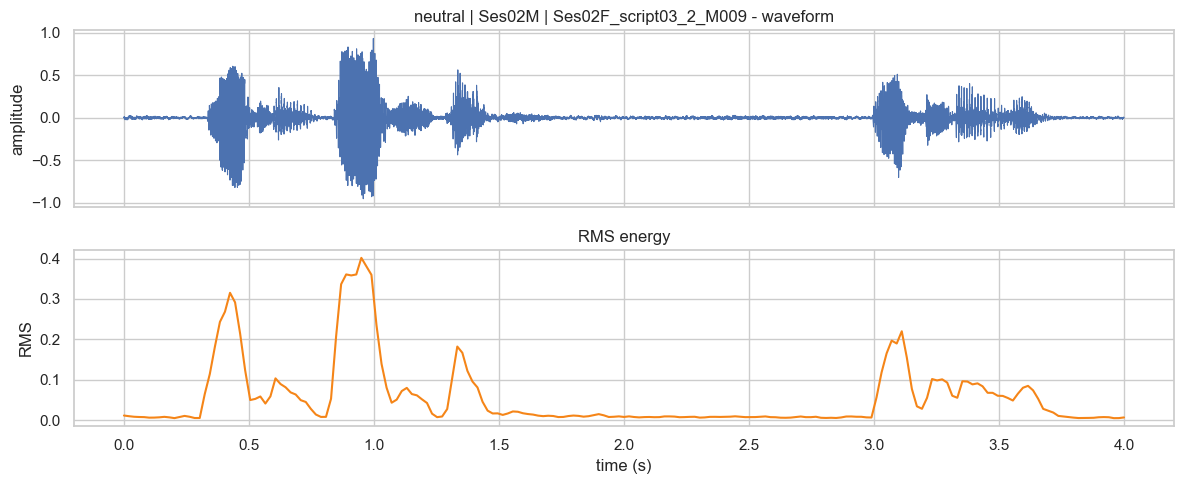

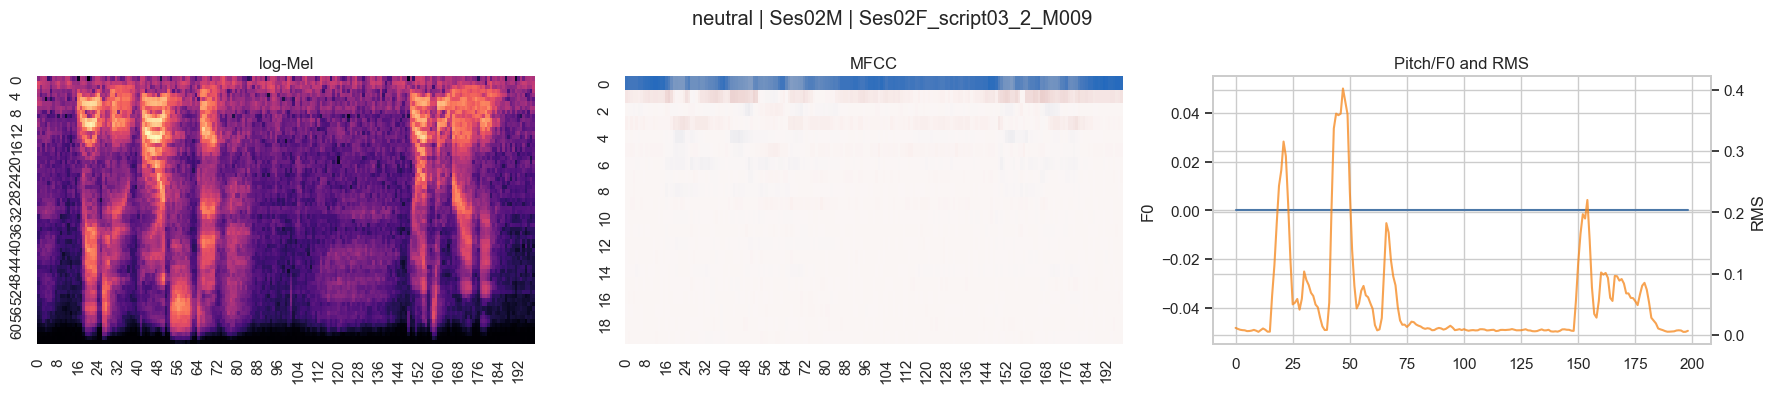

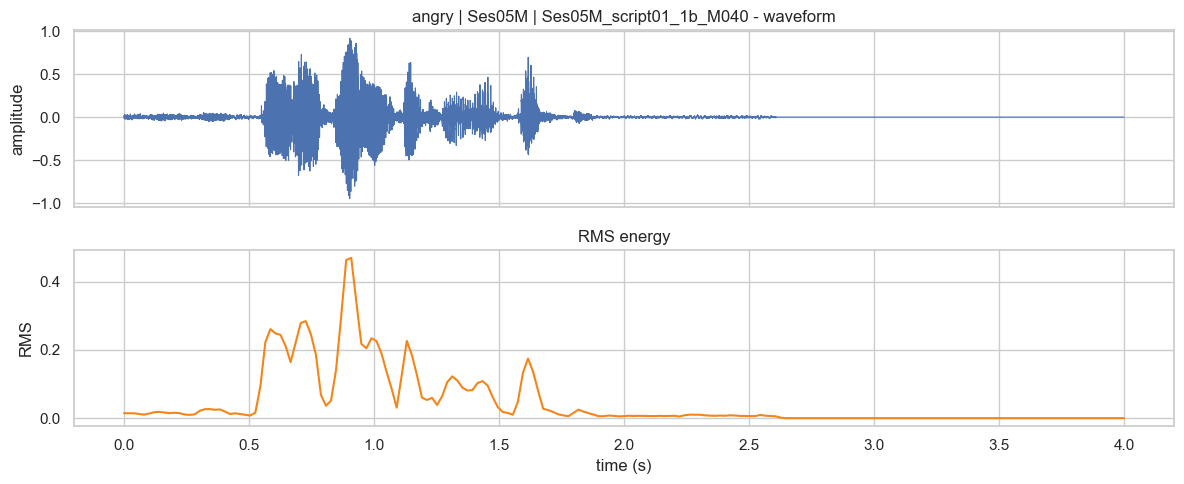

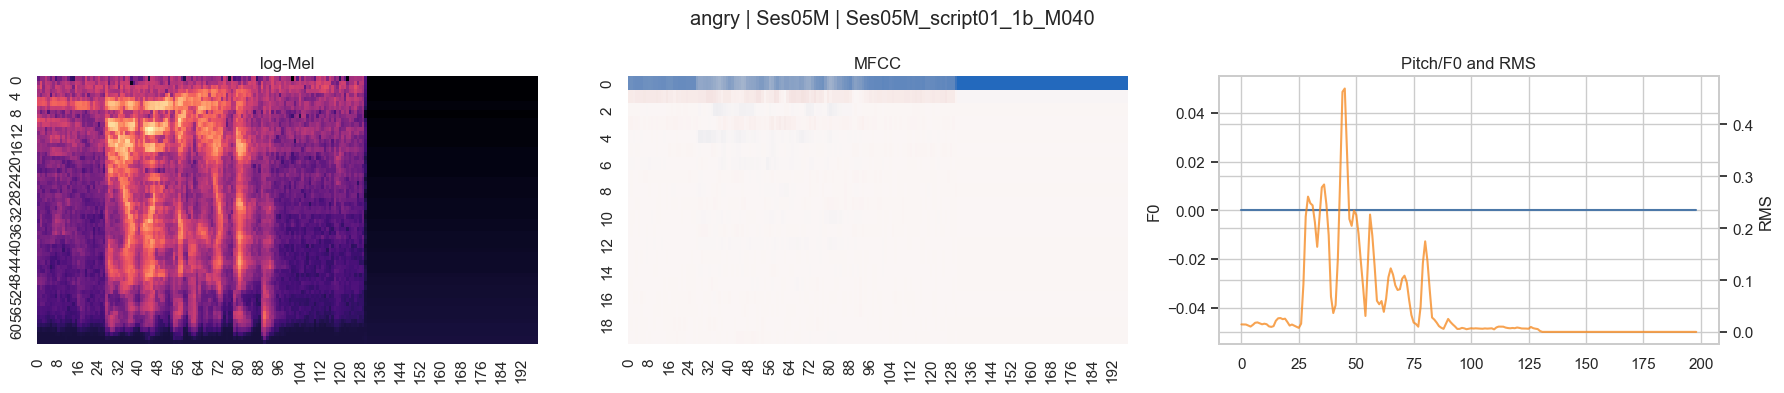

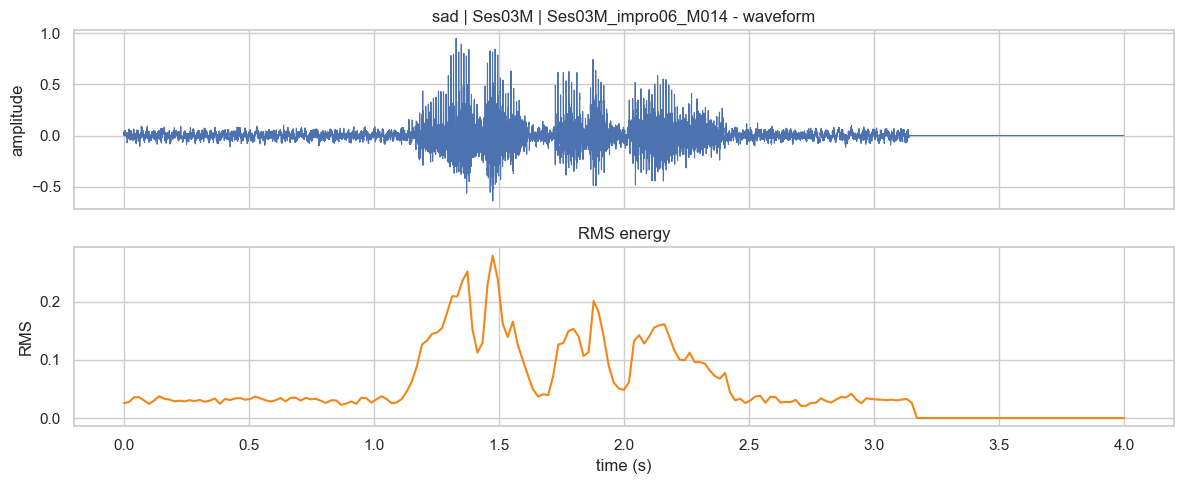

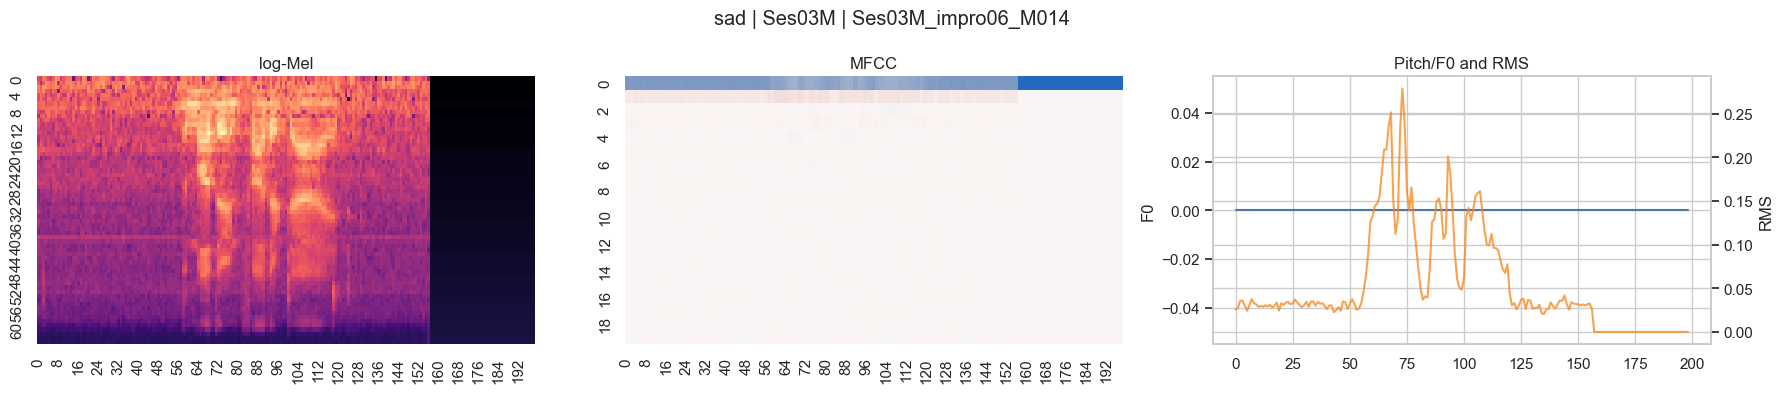

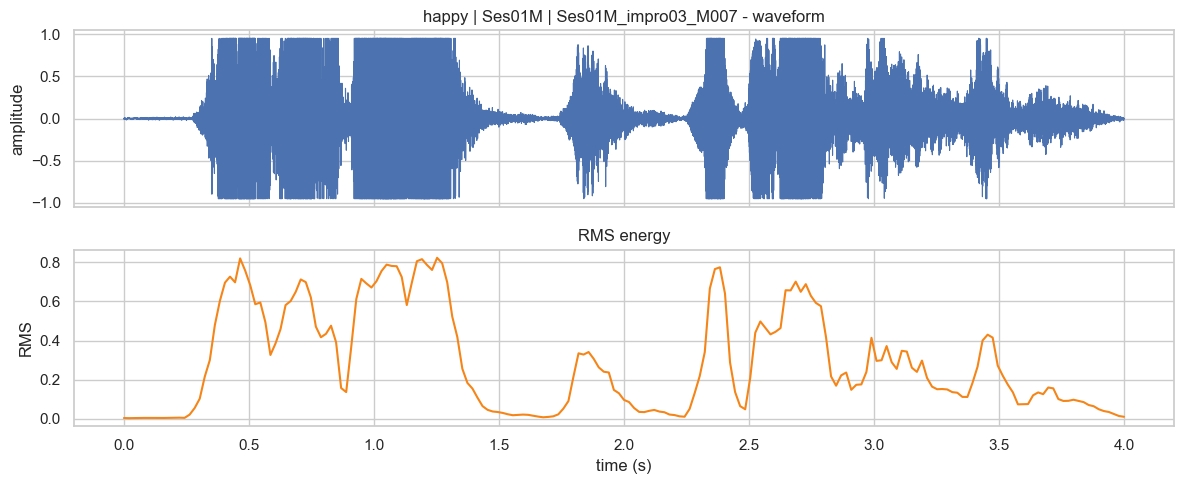

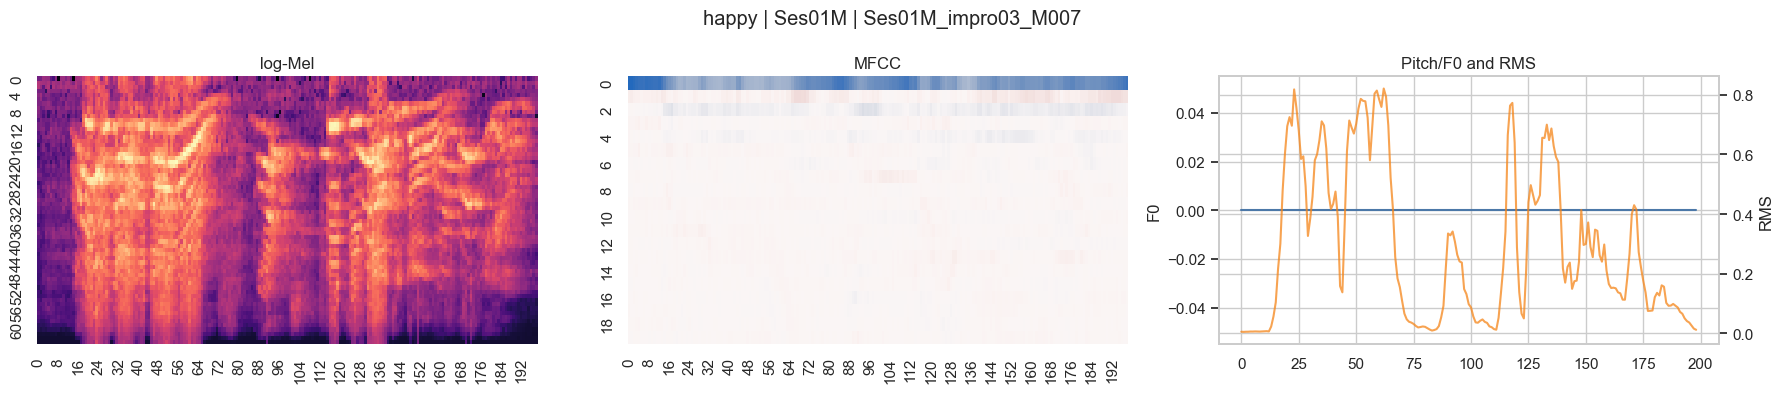

,train_sample_id,utterance_id,speaker_id,emotion_4class,original_sr,original_samples,original_duration,target_sr,processed_samples,processed_duration,peak,rms,duration,wave_peak,wave_rms,f0_mean,rms_mean,zcr_mean
0,iemocap_hf_02669,Ses02F_script03_2_M009,Ses02M,neutral,16000,66400,4.150000,16000,66400,4.150000,0.95,0.099130,4.0,0.95,0.100960,0.0,0.056316,0.135206
1,iemocap_hf_09638,Ses05M_script01_1b_M040,Ses05M,angry,16000,41723,2.607687,16000,41723,2.607687,0.95,0.119719,4.0,0.95,0.096663,0.0,0.046515,0.055198
2,iemocap_hf_05040,Ses03M_impro06_M014,Ses03M,sad,16000,50232,3.139500,16000,50232,3.139500,0.95,0.091739,4.0,0.95,0.081274,0.0,0.054880,0.047527
3,iemocap_hf_01008,Ses01M_impro03_M007,Ses01M,happy,16000,129320,8.082500,16000,129320,8.082500,0.95,0.309168,4.0,0.95,0.390258,0.0,0.292833,0.138009


In [7]:
def plot_waveform_and_rms(y, sr, feats, title, out_path=None):
    times = np.arange(len(y)) / sr
    rms = feats["rms"].squeeze()
    rms_times = np.linspace(0, len(y) / sr, len(rms))
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].plot(times, y, linewidth=0.8)
    axes[0].set_title(title + " - waveform")
    axes[0].set_ylabel("amplitude")
    axes[1].plot(rms_times, rms, color="#F58518", linewidth=1.5)
    axes[1].set_title("RMS energy")
    axes[1].set_xlabel("time (s)")
    axes[1].set_ylabel("RMS")
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()

def plot_feature_heatmaps(feats, title, out_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.heatmap(feats["logmel"], ax=axes[0], cmap="magma", cbar=False)
    axes[0].set_title("log-Mel")
    sns.heatmap(feats["mfcc"], ax=axes[1], cmap="vlag", center=0, cbar=False)
    axes[1].set_title("MFCC")
    pitch = feats["f0"].squeeze()
    rms = feats["rms"].squeeze()
    axes[2].plot(pitch, label="F0", color="#4C78A8")
    axes[2].set_title("Pitch/F0 and RMS")
    ax2 = axes[2].twinx()
    ax2.plot(rms, label="RMS", color="#F58518", alpha=0.75)
    axes[2].set_ylabel("F0")
    ax2.set_ylabel("RMS")
    fig.suptitle(title)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()

def visualize_demo_samples(demo_df):
    if demo_df.empty:
        display(Markdown("Không có demo samples để visualize."))
        return []
    summary_rows = []
    for _, row in demo_df.head(4).iterrows():
        y, sr, prep = preprocess_audio(row["wav_path"])
        segments, seg_info = segment_waveform(y, sr)
        y_seg = segments[0]
        feats, summary = extract_feature_summary(y_seg, sr)
        title = f"{row['emotion_4class']} | {row['speaker_id']} | {row['utterance_id']}"
        safe_id = str(row["train_sample_id"]).replace("/", "_")
        plot_waveform_and_rms(y_seg, sr, feats, title, SAMPLE_DIR / f"{safe_id}_waveform_rms.png")
        plot_feature_heatmaps(feats, title, SAMPLE_DIR / f"{safe_id}_feature_heatmaps.png")
        summary_rows.append({
            "train_sample_id": row["train_sample_id"],
            "utterance_id": row["utterance_id"],
            "speaker_id": row["speaker_id"],
            "emotion_4class": row["emotion_4class"],
            **prep,
            **{k: v for k, v in summary.items() if k in ["duration", "wave_peak", "wave_rms"]},
            "f0_mean": float(np.mean(feats["f0"][feats["f0"] > 0])) if np.any(feats["f0"] > 0) else 0.0,
            "rms_mean": float(np.mean(feats["rms"])),
            "zcr_mean": float(np.mean(feats["zcr"])),
        })
    return summary_rows

if demo_samples.empty:
    demo_summary = pd.DataFrame()
    display(Markdown("Bỏ qua visualization vì chưa có audio metadata."))
else:
    demo_summary = pd.DataFrame(visualize_demo_samples(demo_samples))
    display(demo_summary)
    demo_summary.to_csv(REPORT_DIR / "demo_feature_summary.csv", index=False, encoding="utf-8-sig")

## 8. So sánh cùng speaker/khác emotion và khác speaker/cùng emotion

Phần này giúp phân biệt:

- Feature nào phản ánh emotion.
- Feature nào dễ bị speaker identity chi phối.

Nếu một feature thay đổi mạnh theo speaker nhưng không ổn định theo emotion, feature đó nên dùng làm tín hiệu phụ/gate thay vì backbone chính.

Found comparison groups: ['same_speaker_different_emotion', 'same_emotion_different_speaker', 'same_conversation_different_emotion']


### same_speaker_different_emotion

,train_sample_id,utterance_id,speaker_id,conversation_id,emotion_4class,duration
0,iemocap_hf_00000,Ses01F_impro01_F000,Ses01F,Ses01F_impro01,neutral,1.945563
6,iemocap_hf_00012,Ses01F_impro01_F012,Ses01F,Ses01F_impro01,angry,2.750000


### same_emotion_different_speaker

,train_sample_id,utterance_id,speaker_id,conversation_id,emotion_4class,duration
6,iemocap_hf_00012,Ses01F_impro01_F012,Ses01F,Ses01F_impro01,angry,2.750000
8,iemocap_hf_00027,Ses01F_impro01_M011,Ses01M,Ses01F_impro01,angry,7.239937


### same_conversation_different_emotion

,train_sample_id,utterance_id,speaker_id,conversation_id,emotion_4class,duration
0,iemocap_hf_00000,Ses01F_impro01_F000,Ses01F,Ses01F_impro01,neutral,1.945563
6,iemocap_hf_00012,Ses01F_impro01_F012,Ses01F,Ses01F_impro01,angry,2.750000


,comparison,train_sample_id,emotion_4class,speaker_id,wave_rms,f0_mean,rms_mean,zcr_mean,mfcc0_mean
0,same_speaker_different_emotion,iemocap_hf_00000,neutral,Ses01F,0.091834,0.0,0.036786,0.054273,-608.184692
1,same_speaker_different_emotion,iemocap_hf_00012,angry,Ses01F,0.066557,0.0,0.029694,0.077776,-606.037903
2,same_emotion_different_speaker,iemocap_hf_00012,angry,Ses01F,0.066557,0.0,0.029694,0.077776,-606.037903
3,same_emotion_different_speaker,iemocap_hf_00027,angry,Ses01M,0.038477,0.0,0.026568,0.103433,-547.648743
4,same_conversation_different_emotion,iemocap_hf_00000,neutral,Ses01F,0.091834,0.0,0.036786,0.054273,-608.184692
5,same_conversation_different_emotion,iemocap_hf_00012,angry,Ses01F,0.066557,0.0,0.029694,0.077776,-606.037903


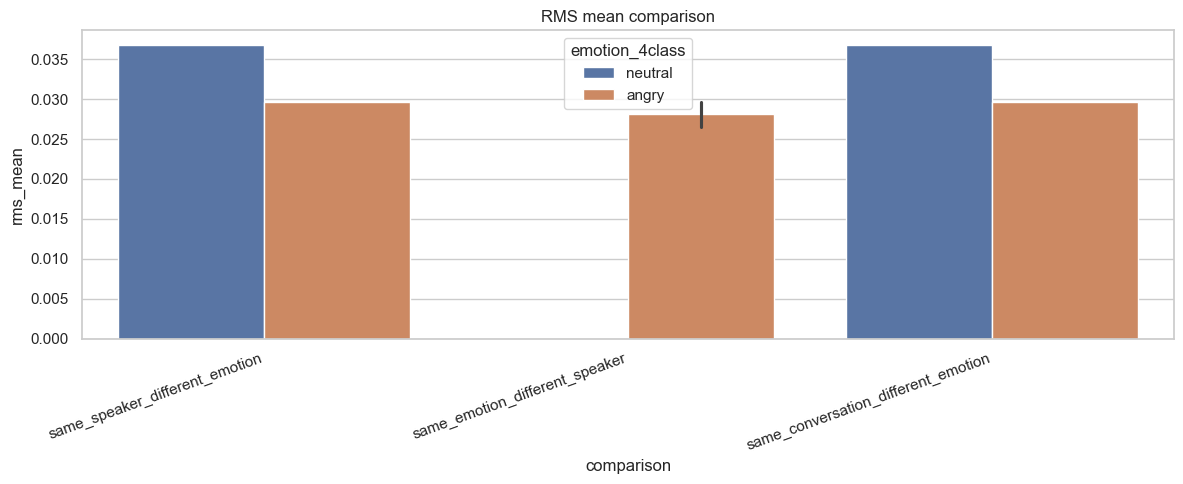

In [8]:
def find_comparison_pairs(df):
    pairs = {}
    if df.empty:
        return pairs
    # Same speaker, different emotions
    for speaker, sub in df.groupby("speaker_id"):
        if sub["emotion_4class"].nunique() >= 2:
            a = sub.iloc[0]
            b = sub[sub["emotion_4class"] != a["emotion_4class"]].iloc[0]
            pairs["same_speaker_different_emotion"] = pd.DataFrame([a, b])
            break
    # Same emotion, different speakers
    for emotion, sub in df.groupby("emotion_4class"):
        if sub["speaker_id"].nunique() >= 2:
            a = sub.iloc[0]
            b = sub[sub["speaker_id"] != a["speaker_id"]].iloc[0]
            pairs["same_emotion_different_speaker"] = pd.DataFrame([a, b])
            break
    # Same conversation, different emotions
    if "conversation_id" in df.columns:
        for conv, sub in df.groupby("conversation_id"):
            if sub["emotion_4class"].nunique() >= 2:
                a = sub.iloc[0]
                b = sub[sub["emotion_4class"] != a["emotion_4class"]].iloc[0]
                pairs["same_conversation_different_emotion"] = pd.DataFrame([a, b])
                break
    return pairs

comparison_pairs = find_comparison_pairs(audio_metadata)
print("Found comparison groups:", list(comparison_pairs.keys()))

comparison_rows = []
for name, pair_df in comparison_pairs.items():
    display(Markdown(f"### {name}"))
    display(pair_df[["train_sample_id", "utterance_id", "speaker_id", "conversation_id", "emotion_4class", "duration"]])
    local_rows = []
    for _, row in pair_df.iterrows():
        y, sr, prep = preprocess_audio(row["wav_path"])
        segments, _ = segment_waveform(y, sr)
        feats, summary = extract_feature_summary(segments[0], sr)
        local_rows.append({
            "comparison": name,
            "train_sample_id": row["train_sample_id"],
            "emotion_4class": row["emotion_4class"],
            "speaker_id": row["speaker_id"],
            "wave_rms": summary["wave_rms"],
            "f0_mean": float(np.mean(feats["f0"][feats["f0"] > 0])) if np.any(feats["f0"] > 0) else 0.0,
            "rms_mean": float(np.mean(feats["rms"])),
            "zcr_mean": float(np.mean(feats["zcr"])),
            "mfcc0_mean": float(np.mean(feats["mfcc"][0])),
        })
    comparison_rows.extend(local_rows)

if comparison_rows:
    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df)
    comparison_df.to_csv(REPORT_DIR / "comparison_pair_feature_summary.csv", index=False, encoding="utf-8-sig")
    plt.figure(figsize=(12, 5))
    sns.barplot(data=comparison_df, x="comparison", y="rms_mean", hue="emotion_4class")
    plt.xticks(rotation=20, ha="right")
    plt.title("RMS mean comparison")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "comparison_pairs_rms_mean.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    display(Markdown("Chưa có comparison pairs vì chưa có audio metadata."))

## 9. Dataset-level feature statistics

Cell này trích thống kê feature trên một subset hoặc toàn bộ dataset.

Mặc định `RUN_FULL_EXTRACTION=False` để tránh chạy lâu khi mới mở notebook. Khi đã chắc pipeline ổn, bật:

```python
RUN_FULL_EXTRACTION = True
```

Output:

```text
reports/feature_summary_subset_or_full.csv
figures/feature_distribution_by_emotion.png
features_cache/acoustic_summary_features.npz
```

Rows selected for acoustic summary extraction: 8


,train_sample_id,utterance_id,speaker_id,session,emotion_4class,n_segments,original_sr,original_samples,original_duration,target_sr,processed_samples,processed_duration,peak,rms,mfcc_0_mean,mfcc_0_std,mfcc_0_min,mfcc_0_max,mfcc_0_median,mfcc_0_iqr,mfcc_1_mean,mfcc_1_std,mfcc_1_min,mfcc_1_max,mfcc_1_median,mfcc_1_iqr,mfcc_2_mean,mfcc_2_std,mfcc_2_min,mfcc_2_max,mfcc_2_median,mfcc_2_iqr,mfcc_3_mean,mfcc_3_std,mfcc_3_min,mfcc_3_max,mfcc_3_median,mfcc_3_iqr,mfcc_4_mean,mfcc_4_std,mfcc_4_min,mfcc_4_max,mfcc_4_median,mfcc_4_iqr,mfcc_5_mean,mfcc_5_std,mfcc_5_min,mfcc_5_max,mfcc_5_median,mfcc_5_iqr,mfcc_6_mean,mfcc_6_std,mfcc_6_min,mfcc_6_max,mfcc_6_median,mfcc_6_iqr,mfcc_7_mean,mfcc_7_std,mfcc_7_min,mfcc_7_max,mfcc_7_median,mfcc_7_iqr,mfcc_8_mean,mfcc_8_std,mfcc_8_min,mfcc_8_max,mfcc_8_median,mfcc_8_iqr,mfcc_9_mean,mfcc_9_std,mfcc_9_min,mfcc_9_max,mfcc_9_median,mfcc_9_iqr,mfcc_10_mean,mfcc_10_std,mfcc_10_min,mfcc_10_max,mfcc_10_median,mfcc_10_iqr,...,harmonic_12_std,harmonic_12_min,harmonic_12_max,harmonic_12_median,harmonic_12_iqr,harmonic_13_mean,harmonic_13_std,harmonic_13_min,harmonic_13_max,harmonic_13_median,harmonic_13_iqr,harmonic_14_mean,harmonic_14_std,harmonic_14_min,harmonic_14_max,harmonic_14_median,harmonic_14_iqr,harmonic_15_mean,harmonic_15_std,harmonic_15_min,harmonic_15_max,harmonic_15_median,harmonic_15_iqr,harmonic_16_mean,harmonic_16_std,harmonic_16_min,harmonic_16_max,harmonic_16_median,harmonic_16_iqr,harmonic_17_mean,harmonic_17_std,harmonic_17_min,harmonic_17_max,harmonic_17_median,harmonic_17_iqr,harmonic_18_mean,harmonic_18_std,harmonic_18_min,harmonic_18_max,harmonic_18_median,harmonic_18_iqr,harmonic_19_mean,harmonic_19_std,harmonic_19_min,harmonic_19_max,harmonic_19_median,harmonic_19_iqr,harmonic_20_mean,harmonic_20_std,harmonic_20_min,harmonic_20_max,harmonic_20_median,harmonic_20_iqr,harmonic_21_mean,harmonic_21_std,harmonic_21_min,harmonic_21_max,harmonic_21_median,harmonic_21_iqr,harmonic_22_mean,harmonic_22_std,harmonic_22_min,harmonic_22_max,harmonic_22_median,harmonic_22_iqr,harmonic_23_mean,harmonic_23_std,harmonic_23_min,harmonic_23_max,harmonic_23_median,harmonic_23_iqr,harmonic_24_mean,harmonic_24_std,harmonic_24_min,harmonic_24_max,harmonic_24_median,harmonic_24_iqr,duration,wave_peak,wave_rms
0,iemocap_hf_02151,Ses02F_impro08_F005,Ses02F,Ses02,neutral,4,16000,129834,8.114625,16000,129834,8.114625,0.95,0.133446,-476.304634,66.642400,-588.413544,-351.519730,-455.598816,113.411926,49.161865,31.192045,-20.913466,108.656500,54.690224,48.511025,-24.804607,27.287886,-89.772373,30.523686,-19.077952,40.853505,15.789082,15.713657,-20.124277,54.933132,13.983610,24.007197,-22.831552,12.037071,-54.520598,1.040107,-21.592137,17.102453,2.090774,13.557071,-30.014736,35.602002,2.903636,18.197378,-13.460483,9.552033,-40.302338,5.196041,-11.602238,13.909436,3.694667,8.372334,-18.609250,24.789785,2.549180,10.768778,-10.123721,7.987047,-34.123869,7.351525,-8.625361,10.866987,-0.208460,6.975066,-20.602619,17.368800,0.298130,8.403051,-3.914097,8.318070,-24.796432,19.339481,-3.838351,10.350293,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.906152,0.125087
1,iemocap_hf_07360,Ses04M_impro08_M028,Ses04M,Ses04,neutral,1,16000,21119,1.319937,16000,21119,1.319937,0.95,0.106920,-661.796021,144.799789,-760.928101,-345.829102,-760.928101,238.455078,12.059522,53.237961,-24.458090,126.923386,-24.458090,103.340057,-8.458428,17.874317,-73.536804,10.529253,0.180425,4.476161,5.069587,13.828267,-2.623100,72.097824,-2.623100,13.059738,-2.831350,6.508755,-30.103703,6.677100,0.067974,0.991061,-0.782200,7.205557,-36.732399,24.651924,-0.833139,0.000000,-5.001529,8.864145,-33.555202,2.188773,0.192955,10.059513,0.154384,3.685959,-10.554473,17.231998,-0.349069,0.000000,-2

Saved: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\02IEMOCAP Feature Extraction Emotion2Vec Acoustic\reports\feature_summary_subset.csv


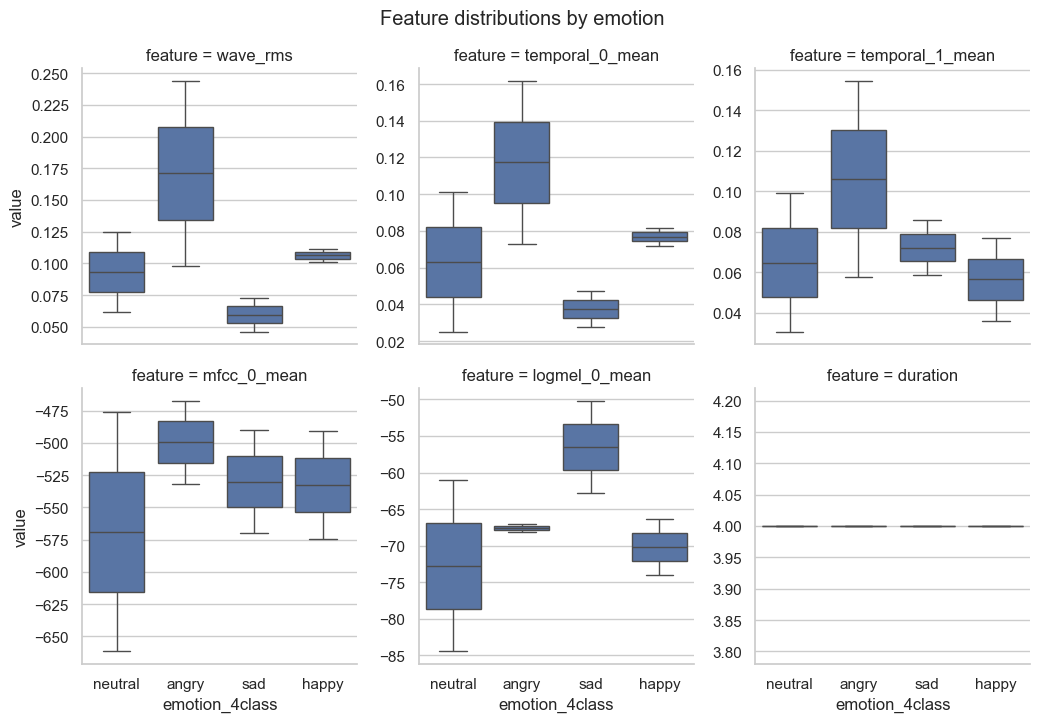

In [9]:
def choose_extraction_rows(df):
    if df.empty:
        return pd.DataFrame()
    if RUN_FULL_EXTRACTION:
        return df.copy().reset_index(drop=True)
    parts = []
    for emotion in FOUR_CLASS_EMOTIONS:
        sub = df[df["emotion_4class"].eq(emotion)]
        if not sub.empty:
            parts.append(sub.sample(min(2, len(sub)), random_state=123))
    return pd.concat(parts).drop_duplicates("train_sample_id").reset_index(drop=True) if parts else pd.DataFrame()

extract_rows = choose_extraction_rows(audio_metadata)
print("Rows selected for acoustic summary extraction:", len(extract_rows))

summary_feature_rows = []
failed_rows = []
if extract_rows.empty:
    display(Markdown("Không có audio để trích dataset-level feature statistics."))
else:
    for _, row in extract_rows.iterrows():
        try:
            y, sr, prep = preprocess_audio(row["wav_path"])
            segments, seg_info = segment_waveform(y, sr)
            # For summary statistics, aggregate over first segments then average scalar summaries.
            segment_summaries = []
            for seg in segments:
                _, summary = extract_feature_summary(seg, sr)
                segment_summaries.append(summary)
            avg_summary = pd.DataFrame(segment_summaries).mean(numeric_only=True).to_dict()
            summary_feature_rows.append({
                "train_sample_id": row["train_sample_id"],
                "utterance_id": row["utterance_id"],
                "speaker_id": row["speaker_id"],
                "session": row["session"],
                "emotion_4class": row["emotion_4class"],
                "n_segments": len(segments),
                **prep,
                **avg_summary,
            })
        except Exception as exc:
            failed_rows.append({"train_sample_id": row.get("train_sample_id"), "wav_path": row.get("wav_path"), "error": str(exc)})

summary_features_df = pd.DataFrame(summary_feature_rows)
failed_df = pd.DataFrame(failed_rows)

if not summary_features_df.empty:
    out_csv = REPORT_DIR / ("feature_summary_full.csv" if RUN_FULL_EXTRACTION else "feature_summary_subset.csv")
    summary_features_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    display(summary_features_df.head())
    print("Saved:", out_csv)
    key_cols = [c for c in ["wave_rms", "temporal_0_mean", "temporal_1_mean", "mfcc_0_mean", "logmel_0_mean", "duration"] if c in summary_features_df.columns]
    if key_cols:
        melted = summary_features_df.melt(id_vars=["emotion_4class"], value_vars=key_cols, var_name="feature", value_name="value")
        g = sns.catplot(data=melted, x="emotion_4class", y="value", col="feature", kind="box", col_wrap=3, sharey=False, height=3.5)
        g.fig.suptitle("Feature distributions by emotion", y=1.03)
        plt.savefig(FIGURE_DIR / "feature_distribution_by_emotion.png", dpi=160, bbox_inches="tight")
        plt.show()
    numeric_cols = summary_features_df.select_dtypes(include=[np.number]).columns.tolist()
    np.savez_compressed(
        CACHE_DIR / "acoustic_summary_features.npz",
        sample_ids=summary_features_df["train_sample_id"].to_numpy(),
        feature_names=np.array(numeric_cols),
        X=summary_features_df[numeric_cols].to_numpy(dtype=np.float32),
    )
if not failed_df.empty:
    failed_df.to_csv(REPORT_DIR / "feature_extraction_failed_rows.csv", index=False, encoding="utf-8-sig")
    display(failed_df)

## 10. Emotion2Vec feature extraction

`emotion2vec` là feature extractor chính trong hướng đề tài này.

Khuyến nghị:

- Không dùng zero embedding âm thầm nếu extractor lỗi.
- Nếu lỗi, ghi log file fail.
- Cache embedding ra file `.npz`.
- Với utterance dài, dùng segment-level embeddings rồi aggregate bằng mean/attention ở model sau.

Cell dưới đây viết theo hướng an toàn: nếu `funasr` hoặc model chưa sẵn sàng, notebook không crash toàn bộ mà ghi rõ cần cài/cấu hình.

In [10]:
def try_load_emotion2vec(model_name="iic/emotion2vec_base"):
    try:
        from funasr import AutoModel
        model = AutoModel(model=model_name, hub="ms")
        return model, None
    except Exception as exc:
        return None, str(exc)

def find_numeric_embedding(obj):
    if isinstance(obj, np.ndarray):
        return obj
    if isinstance(obj, (list, tuple)):
        for item in obj:
            found = find_numeric_embedding(item)
            if found is not None:
                return found
    if isinstance(obj, dict):
        preferred = ["feats", "embedding", "xvector", "hidden_states", "outputs"]
        for key in preferred + list(obj.keys()):
            if key in obj:
                found = find_numeric_embedding(obj[key])
                if found is not None:
                    return found
    return None

RUN_EMOTION2VEC_EXTRACTION = False
EMOTION2VEC_MODEL_NAME = "iic/emotion2vec_base"

if not RUN_EMOTION2VEC_EXTRACTION:
    display(Markdown("""
`RUN_EMOTION2VEC_EXTRACTION=False` hiện đang tắt để tránh tải/chạy model nặng khi chỉ đọc notebook.

Khi đã có IEMOCAP và môi trường sẵn sàng, bật:

```python
RUN_EMOTION2VEC_EXTRACTION = True
```

Sau đó chạy lại cell này để tạo `emotion2vec_embeddings.npz`.
"""))
else:
    model, err = try_load_emotion2vec(EMOTION2VEC_MODEL_NAME)
    if model is None:
        display(Markdown(f"Không load được emotion2vec: `{err}`"))
    elif audio_metadata.empty:
        display(Markdown("Không có audio metadata để extract emotion2vec."))
    else:
        rows = audio_metadata if RUN_FULL_EXTRACTION else choose_extraction_rows(audio_metadata)
        embeddings, ids, failures = [], [], []
        for _, row in rows.iterrows():
            try:
                result = model.generate(str(row["wav_path"]), granularity="utterance", extract_embedding=True)
                emb = find_numeric_embedding(result)
                if emb is None:
                    raise ValueError("No numeric embedding found in emotion2vec output.")
                emb = np.asarray(emb, dtype=np.float32).reshape(-1)
                embeddings.append(emb)
                ids.append(row["train_sample_id"])
            except Exception as exc:
                failures.append({"train_sample_id": row["train_sample_id"], "wav_path": row["wav_path"], "error": str(exc)})
        if embeddings:
            max_dim = max(len(e) for e in embeddings)
            X = np.zeros((len(embeddings), max_dim), dtype=np.float32)
            for i, e in enumerate(embeddings):
                X[i, :len(e)] = e
            np.savez_compressed(CACHE_DIR / "emotion2vec_embeddings.npz", sample_ids=np.array(ids), X=X)
            print("Saved:", CACHE_DIR / "emotion2vec_embeddings.npz", X.shape)
        if failures:
            pd.DataFrame(failures).to_csv(REPORT_DIR / "emotion2vec_failed_rows.csv", index=False, encoding="utf-8-sig")
            display(pd.DataFrame(failures).head())


`RUN_EMOTION2VEC_EXTRACTION=False` hiện đang tắt để tránh tải/chạy model nặng khi chỉ đọc notebook.

Khi đã có IEMOCAP và môi trường sẵn sàng, bật:

```python
RUN_EMOTION2VEC_EXTRACTION = True
```

Sau đó chạy lại cell này để tạo `emotion2vec_embeddings.npz`.


## 11. Output report

Sau khi chạy notebook với dataset thật, folder 02 sẽ có:

```text
02IEMOCAP Feature Extraction Emotion2Vec Acoustic/
  reports/
    feature_reference_table.csv
    selected_demo_samples.csv
    demo_feature_summary.csv
    comparison_pair_feature_summary.csv
    feature_summary_subset.csv hoặc feature_summary_full.csv
    feature_extraction_failed_rows.csv nếu có lỗi
    emotion2vec_failed_rows.csv nếu có lỗi

  figures/
    feature_distribution_by_emotion.png
    comparison_pairs_rms_mean.png

  sample_visualizations/
    *_waveform_rms.png
    *_feature_heatmaps.png

  features_cache/
    acoustic_summary_features.npz
    emotion2vec_embeddings.npz nếu bật extraction
```

In [11]:
from pathlib import Path

selected_path = REPORT_DIR / "selected_demo_samples.csv"
demo_path = REPORT_DIR / "demo_feature_summary.csv"
comparison_path = REPORT_DIR / "comparison_pair_feature_summary.csv"
feature_subset_path = REPORT_DIR / "feature_summary_subset.csv"

selected_df = pd.read_csv(selected_path) if selected_path.exists() else pd.DataFrame()
demo_df = pd.read_csv(demo_path) if demo_path.exists() else pd.DataFrame()
comparison_df = pd.read_csv(comparison_path) if comparison_path.exists() else pd.DataFrame()
feature_subset_df = pd.read_csv(feature_subset_path) if feature_subset_path.exists() else pd.DataFrame()
cache_files = sorted(p.name for p in CACHE_DIR.glob("*")) if "CACHE_DIR" in globals() else []
emotion2vec_cache_exists = any("emotion2vec" in name.lower() for name in cache_files)
sample_vis_dir = SAMPLE_DIR if "SAMPLE_DIR" in globals() else Path("sample_visualizations")

report_lines = [
    "# Feature Extraction Notebook 02 Summary",
    "",
    "## Current execution status",
    "",
    f"- Metadata path: `{METADATA_PATH}`",
    f"- Metadata available: **{METADATA_PATH.exists()}**.",
    f"- Rows with existing wav: **{len(audio_metadata) if 'audio_metadata' in globals() else 0:,}**.",
    f"- Selected demo samples: **{len(selected_df)}**.",
    f"- Feature cache rows in this run: **{len(feature_subset_df)}**.",
    f"- Cache files: **{', '.join(cache_files) if cache_files else 'none'}**.",
    f"- Emotion2vec embedding cache exists: **{emotion2vec_cache_exists}**.",
    f"- Target sample rate: **{TARGET_SR} Hz**.",
    f"- Segment seconds: **{SEGMENT_SECONDS}**.",
    f"- Segment overlap: **{SEGMENT_OVERLAP}**.",
    f"- Peak normalize: **{PEAK_NORMALIZE}**.",
    f"- RMS normalize: **{RMS_NORMALIZE}**.",
    "",
    "Important: this run intentionally keeps feature extraction small for inspection. The current cache is a demo/subset "
    "cache, not the final full feature cache for all 6,877 utterances.",
    "",
    "## Preprocessing meaning",
    "",
    "Before handcrafted features or pretrained speech embeddings, every waveform should be loaded, converted to mono, "
    "resampled to 16 kHz when needed, amplitude-normalized, and segmented/padded consistently. Pretrained models such "
    "as emotion2vec/wav2vec2/WavLM consume raw waveform, so MFCC/log-Mel are not required as their input, but the waveform "
    "normalization still matters.",
    "",
    "## Feature groups and intended role",
    "",
]
for row in feature_reference_rows:
    report_lines.append(f"- **{row['feature_group']}**: {row['used_by_future_model']}")

report_lines += [
    "",
    "## Observations from demo samples",
    "",
]
if not demo_df.empty:
    demo_table = demo_df[
        ["emotion_4class", "train_sample_id", "original_duration", "wave_rms", "rms_mean", "zcr_mean"]
    ].sort_values("emotion_4class").round(4)
    report_lines += [
        demo_table.to_markdown(index=False),
        "",
        "The selected happy sample has visibly higher RMS in this tiny demo set. This is useful as a visual sanity check, "
        "but it is not yet a dataset-level conclusion.",
        "",
    ]
else:
    report_lines.append("- Demo feature table was not generated.")

report_lines += [
    "## Same-speaker / different-speaker checks",
    "",
]
if not comparison_df.empty:
    comparison_table = comparison_df[
        ["comparison", "train_sample_id", "emotion_4class", "speaker_id", "wave_rms", "rms_mean", "zcr_mean", "mfcc0_mean"]
    ].round(4)
    report_lines += [
        comparison_table.to_markdown(index=False),
        "",
        "These comparisons show why random split is risky: handcrafted acoustic values change with speaker and conversation, "
        "not only emotion. The next training notebooks should keep 5-fold and 10-fold speaker-independent protocols.",
        "",
    ]
else:
    report_lines.append("- Comparison table was not generated.")

report_lines += [
    "## Caveats before model training",
    "",
    "- The fast extractor uses SciPy/Numpy STFT + Mel filterbank + DCT for MFCC-like/log-Mel inspection because some "
    "`librosa.feature` calls were too slow in this environment.",
    "- Do not use `f0_mean=0` from the fast extractor as pitch evidence. Use HuggingFace metadata pitch fields or a stable "
    "pitch extractor such as pyworld/praat-parselmouth later.",
    "- Do not silently replace failed emotion2vec embeddings with zeros. Missing embeddings should stop the extraction step.",
    "- Full extraction should be enabled only after the final extractor is chosen.",
    "",
    "## Generated visual outputs",
    "",
    f"- Overview figures: **{len(list(FIGURE_DIR.glob('*.png')))}**.",
    f"- Sample visualizations: **{len(list(sample_vis_dir.glob('*.png')))}**.",
    "",
    "## Next step",
    "",
    "The next implementation step is real emotion2vec embedding extraction for the full 4-class IEMOCAP subset, then "
    "segment/utterance pooling aligned with both 5-fold session-independent and 10-fold speaker-independent splits.",
]

summary_path = REPORT_DIR / "02_feature_extraction_summary.md"
summary_path.write_text("\n".join(report_lines), encoding="utf-8")
audit_path = REPORT_DIR / "notebook02_output_audit_and_interpretation.md"
audit_path.write_text("\n".join(report_lines), encoding="utf-8")
display(Markdown("\n".join(report_lines)))
print("Saved:", summary_path)
print("Saved audit:", audit_path)


# Feature Extraction Notebook 02 Summary

## Current execution status

- Metadata path: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\metadata\iemocap_4class_avd_metadata.csv`
- Metadata available: **True**.
- Rows with existing wav: **6,877**.
- Selected demo samples: **4**.
- Feature cache rows in this run: **8**.
- Cache files: **acoustic_summary_features.npz**.
- Emotion2vec embedding cache exists: **False**.
- Target sample rate: **16000 Hz**.
- Segment seconds: **4.0**.
- Segment overlap: **0.5**.
- Peak normalize: **True**.
- RMS normalize: **False**.

Important: this run intentionally keeps feature extraction small for inspection. The current cache is a demo/subset cache, not the final full feature cache for all 6,877 utterances.

## Preprocessing meaning

Before handcrafted features or pretrained speech embeddings, every waveform should be loaded, converted to mono, resampled to 16 kHz when needed, amplitude-normalized, and segmented/padded consistently. Pretrained models such as emotion2vec/wav2vec2/WavLM consume raw waveform, so MFCC/log-Mel are not required as their input, but the waveform normalization still matters.

## Feature groups and intended role

- **emotion2vec embeddings**: main backbone / shared encoder
- **MFCC + delta + delta-delta**: 1D CNN/BiLSTM acoustic support branch
- **log-Mel + delta + delta-delta**: 2D CNN / spectral branch
- **Pitch/F0**: prosody branch / statistical gate
- **RMS energy**: prosody branch / arousal support
- **ZCR**: temporal support branch
- **Chroma / Tonnetz**: optional statistical/acoustic ablation
- **Spectral contrast**: statistical branch / ablation
- **Statistical functionals**: statistical gate / auxiliary feature vector

## Observations from demo samples

| emotion_4class   | train_sample_id   |   original_duration |   wave_rms |   rms_mean |   zcr_mean |
|:-----------------|:------------------|--------------------:|-----------:|-----------:|-----------:|
| angry            | iemocap_hf_09638  |              2.6077 |     0.0967 |     0.0465 |     0.0552 |
| happy            | iemocap_hf_01008  |              8.0825 |     0.3903 |     0.2928 |     0.138  |
| neutral          | iemocap_hf_02669  |              4.15   |     0.101  |     0.0563 |     0.1352 |
| sad              | iemocap_hf_05040  |              3.1395 |     0.0813 |     0.0549 |     0.0475 |

The selected happy sample has visibly higher RMS in this tiny demo set. This is useful as a visual sanity check, but it is not yet a dataset-level conclusion.

## Same-speaker / different-speaker checks

| comparison                          | train_sample_id   | emotion_4class   | speaker_id   |   wave_rms |   rms_mean |   zcr_mean |   mfcc0_mean |
|:------------------------------------|:------------------|:-----------------|:-------------|-----------:|-----------:|-----------:|-------------:|
| same_speaker_different_emotion      | iemocap_hf_00000  | neutral          | Ses01F       |     0.0918 |     0.0368 |     0.0543 |     -608.185 |
| same_speaker_different_emotion      | iemocap_hf_00012  | angry            | Ses01F       |     0.0666 |     0.0297 |     0.0778 |     -606.038 |
| same_emotion_different_speaker      | iemocap_hf_00012  | angry            | Ses01F       |     0.0666 |     0.0297 |     0.0778 |     -606.038 |
| same_emotion_different_speaker      | iemocap_hf_00027  | angry            | Ses01M       |     0.0385 |     0.0266 |     0.1034 |     -547.649 |
| same_conversation_different_emotion | iemocap_hf_00000  | neutral          | Ses01F       |     0.0918 |     0.0368 |     0.0543 |     -608.185 |
| same_conversation_different_emotion | iemocap_hf_00012  | angry            | Ses01F       |     0.0666 |     0.0297 |     0.0778 |     -606.038 |

These comparisons show why random split is risky: handcrafted acoustic values change with speaker and conversation, not only emotion. The next training notebooks should keep 5-fold and 10-fold speaker-independent protocols.

## Caveats before model training

- The fast extractor uses SciPy/Numpy STFT + Mel filterbank + DCT for MFCC-like/log-Mel inspection because some `librosa.feature` calls were too slow in this environment.
- Do not use `f0_mean=0` from the fast extractor as pitch evidence. Use HuggingFace metadata pitch fields or a stable pitch extractor such as pyworld/praat-parselmouth later.
- Do not silently replace failed emotion2vec embeddings with zeros. Missing embeddings should stop the extraction step.
- Full extraction should be enabled only after the final extractor is chosen.

## Generated visual outputs

- Overview figures: **2**.
- Sample visualizations: **8**.

## Next step

The next implementation step is real emotion2vec embedding extraction for the full 4-class IEMOCAP subset, then segment/utterance pooling aligned with both 5-fold session-independent and 10-fold speaker-independent splits.

Saved: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\02IEMOCAP Feature Extraction Emotion2Vec Acoustic\reports\02_feature_extraction_summary.md
Saved audit: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\02IEMOCAP Feature Extraction Emotion2Vec Acoustic\reports\notebook02_output_audit_and_interpretation.md


## 12. Kết luận cho bước 2

Notebook này chuẩn bị dữ liệu cho các notebook train:

```text
03_MultiTask_Emotion2Vec_CoAttention_5Fold.ipynb
04_MultiTask_Emotion2Vec_CoAttention_10Fold.ipynb
```

Điểm cần nhớ:

- `emotion2vec` là feature chính.
- MFCC/log-Mel/prosody/statistical features là feature phụ để fusion/gate/cross-attention.
- Các hình minh họa ở notebook này dùng để giải thích và quyết định ablation.
- Nếu feature phụ không cải thiện strict split, vẫn có giá trị phân tích nhưng không nên ép vào model chính.

<!-- CODEx output audit v2 -->

## 10. Kiểm tra output và nhận xét sau khi chạy feature notebook

Phần này kiểm tra output thực tế của notebook 02 sau khi đã có metadata/audio từ HuggingFace. Mục tiêu là phân biệt rõ ba lớp việc: chuẩn hóa audio, trích acoustic feature minh họa, và phần emotion2vec embedding sẽ chạy ở bước tiếp theo khi môi trường model sẵn sàng.

### Trạng thái chạy hiện tại

- Số sample demo được chọn để visualize: **4** mẫu, mỗi emotion một mẫu.
- Số dòng trong cache feature hiện tại: **8** dòng. Đây là **subset minh họa**, không phải full cache cho toàn bộ **6,877** utterances.
- Số nhóm feature trong bảng tham chiếu: **9** dòng mô tả, gồm: **emotion2vec embeddings, MFCC + delta + delta-delta, log-Mel + delta + delta-delta, Pitch/F0, RMS energy, ZCR, Chroma / Tonnetz, Spectral contrast, Statistical functionals**.
- Figures tổng quan: **2** PNG.
- Figures theo từng sample: **8** PNG.
- Cache hiện có: **acoustic_summary_features.npz**.
- Emotion2vec embedding cache: **chưa có**.

Điểm cần ghi rõ: trong lần chạy này, notebook đang ưu tiên chạy ổn định phần acoustic demo bằng SciPy/Numpy. Một số hàm `librosa.feature` trong môi trường hiện tại chạy quá chậm/hang, nên phần demo dùng STFT + Mel filterbank + DCT để tạo MFCC-like/log-Mel feature. Điều này đủ để phân tích pipeline, visualization và kiểm thử preprocessing, nhưng chưa nên xem là feature extractor cuối cùng để train mô hình chính.

### Chuẩn hóa audio trước khi trích feature

Notebook thực hiện các bước chuẩn hóa cơ bản:

- Load audio từ WAV đã export.
- Ép về mono nếu cần.
- Resample về **16 kHz** nếu sample rate khác.
- Peak normalize về mức ổn định để giảm khác biệt âm lượng ghi âm.
- Giữ lại duration thật và dùng segment length **4 giây** cho minh họa.

Các bước này phải làm trước MFCC/log-Mel/emotion2vec vì đặc trưng âm thanh phụ thuộc trực tiếp vào sample rate, số kênh, scale biên độ và độ dài tín hiệu. Với pretrained speech model như emotion2vec/wav2vec2/WavLM, mô hình nhận **raw waveform** nên không cần MFCC làm input chính, nhưng vẫn cần chuẩn hóa waveform.

### Quan sát từ 4 mẫu minh họa

| Emotion | Sample | Duration(s) | Wave RMS | Frame RMS mean | ZCR mean |
|---|---:|---:|---:|---:|---:|
| angry | iemocap_hf_09638 | 2.608 | 0.0967 | 0.0465 | 0.0552 |
| happy | iemocap_hf_01008 | 8.082 | 0.3903 | 0.2928 | 0.1380 |
| neutral | iemocap_hf_02669 | 4.150 | 0.1010 | 0.0563 | 0.1352 |
| sad | iemocap_hf_05040 | 3.139 | 0.0813 | 0.0549 | 0.0475 |

Nhận xét: mẫu `happy` được chọn có RMS lớn hơn rõ trong nhóm demo, nhưng đây chỉ là minh họa trực quan trên vài mẫu, chưa phải kết luận thống kê toàn dataset. Các hình waveform/RMS và heatmap giúp kiểm tra feature có thay đổi theo thời gian, có bị blank, bị clipping hoặc bị padding/truncation sai hay không.

### So sánh cùng speaker, khác emotion và khác speaker

| Comparison | Sample | Emotion | Speaker | Wave RMS | Frame RMS | ZCR | MFCC0 mean |
|---|---:|---|---|---:|---:|---:|---:|
| same_speaker_different_emotion | iemocap_hf_00000 | neutral | Ses01F | 0.0918 | 0.0368 | 0.0543 | -608.18 |
| same_speaker_different_emotion | iemocap_hf_00012 | angry | Ses01F | 0.0666 | 0.0297 | 0.0778 | -606.04 |
| same_emotion_different_speaker | iemocap_hf_00012 | angry | Ses01F | 0.0666 | 0.0297 | 0.0778 | -606.04 |
| same_emotion_different_speaker | iemocap_hf_00027 | angry | Ses01M | 0.0385 | 0.0266 | 0.1034 | -547.65 |
| same_conversation_different_emotion | iemocap_hf_00000 | neutral | Ses01F | 0.0918 | 0.0368 | 0.0543 | -608.18 |
| same_conversation_different_emotion | iemocap_hf_00012 | angry | Ses01F | 0.0666 | 0.0297 | 0.0778 | -606.04 |

Nhận xét: so sánh này cho thấy feature thay đổi không chỉ theo emotion mà còn theo speaker/conversation. Đây là lý do roadmap cần giữ split speaker-independent ngay từ đầu; nếu random split, mô hình dễ học giọng người nói thay vì học tín hiệu cảm xúc.

### Phần cần chạy tiếp để thành feature notebook hoàn chỉnh

- Bật full extraction sau khi thống nhất extractor cuối cùng: không nên full-cache nếu còn dùng bản fast demo.
- Với mô hình chính, dùng emotion2vec embedding làm nhánh semantic/acoustic representation chính.
- Acoustic handcrafted feature nên đóng vai trò nhánh bổ sung: energy/RMS, ZCR, spectral summary, pitch metadata hoặc pitch extractor ổn định hơn.
- Không dùng `f0_mean=0` từ fast extractor làm kết luận pitch. Trong metadata HuggingFace đã có `pitch_mean`/`pitch_std`; nếu cần pitch thật từ waveform, nên dùng `pyworld`, `praat-parselmouth`, hoặc extractor ổn định khác.

Kết luận cho notebook 02: notebook đã đủ để kiểm tra preprocessing, visualization, bảng feature và logic demo; nhưng trước khi train mô hình chính cần bổ sung bước emotion2vec embedding thật và full cache theo 5-fold/10-fold split.
